# Reintegration Readiness Predictor
**IS 455 INTEX Project — Case Management Domain**

| | |
|---|---|
| **Paradigm** | Predictive (Binary Classification) |
| **Sprint Rule** | Problems first, deployment second, quality last |
| **Target** | `reintegration_status == "Completed"` |
| **Primary Metrics** | ROC-AUC · F0.5 · Precision |


## 1. Problem Framing

### Business Problem
The founders of this non-profit safehouse need an **early warning system** to identify when a
resident is approaching readiness for reintegration. Case managers carry high caseloads — without
a systematic flag, residents who are genuinely ready may be held too long (wasted resources, lost
independence momentum) or transitioned too early (relapse risk, safety concerns).

### Why Predictive, Not Explanatory
This pipeline follows **Paradigm B: Predictive Modeling**. The operational need is a *score*, not
an explanation: "Is Resident #42 likely ready right now?" A complex, less-interpretable model is
acceptable — even preferred — if it improves out-of-sample predictive accuracy. We are not
attempting to prove causal mechanisms in this notebook.

### Target Variable
`reintegration_status` from the `residents` table, binarized:

| Value | Target | Interpretation |
|---|---|---|
| `"Completed"` | **1** | Resident successfully reintegrated |
| `"Active"`, `"On Hold"`, `"Transfer"` | **0** | Not yet / not successfully reintegrated |

### Who Cares and Why
- **Case managers:** Need to know which residents to prioritize for exit planning conversations
- **Executive leadership:** Needs to forecast resource availability and bed turnover
- **The residents themselves:** Early identification enables a smoother, more supported transition

### Leakage Risk (Critical)
The `residents` table contains post-outcome fields that MUST be dropped before any modeling:

| Column | Why it Leaks |
|---|---|
| `date_closed` | Only populated when a resident exits — a direct consequence of completion |
| `case_status = "Closed"` | Directly encodes the outcome we are predicting |

A dedicated leakage audit cell below verifies these are absent from the modeling DataFrame.

### Metric Priority
Given class imbalance (~30% positive) and the asymmetric cost of errors, we prioritize:
1. **ROC-AUC** — threshold-agnostic discrimination ability
2. **Precision** — minimize premature releases (false positives are higher cost)
3. **F0.5** — composite score weighting precision heavily; used for threshold selection on the PR curve
4. **Log Loss** — probabilistic calibration quality


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    log_loss, precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay, f1_score, fbeta_score,
)
from sklearn.inspection import permutation_importance
import joblib, json, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

# sklearn >= 1.2 required for sparse_output=False in OneHotEncoder
import sklearn; print(f"sklearn {sklearn.__version__}")
print("All libraries loaded successfully.")


sklearn 1.8.0
All libraries loaded successfully.


## 2. Data Acquisition, Preparation & Exploration

> **Production swap-in:** When the PostgreSQL database is live, replace the synthetic block below
> with the commented SQLAlchemy queries. All downstream feature engineering code is identical.
>
> ```python
> import os
> from sqlalchemy import create_engine
> engine = create_engine(os.environ["DATABASE_URL"])
> with engine.connect() as conn:
>     df_residents     = pd.read_sql("SELECT * FROM residents",               conn)
>     df_process       = pd.read_sql("SELECT * FROM process_recordings",      conn)
>     df_education     = pd.read_sql("SELECT * FROM education_records",       conn)
>     df_health        = pd.read_sql("SELECT * FROM health_wellbeing_records", conn)
>     df_incidents     = pd.read_sql("SELECT * FROM incident_reports",        conn)
>     df_interventions = pd.read_sql("SELECT * FROM intervention_plans",      conn)
> ```


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SYNTHETIC DATA GENERATION
# All features are correlated through a shared latent `readiness` score so the
# model has realistic signal. Remove this block and use DB queries above in production.
# ─────────────────────────────────────────────────────────────────────────────
N = 600
readiness = np.random.normal(0, 1, N)   # latent variable driving all features

# ── residents ────────────────────────────────────────────────────────────────
reint_status = np.where(
    readiness + np.random.normal(0, 0.6, N) > 0.7,
    'Completed',
    np.random.choice(['Active', 'On Hold', 'Transfer'], N, p=[0.60, 0.25, 0.15])
)

df_residents = pd.DataFrame({
    'resident_id':          range(1, N + 1),
    'safehouse_id':         np.random.choice(['SH001', 'SH002', 'SH003', 'SH004'], N),
    'age_at_entry':         np.random.randint(13, 21, N),
    'days_in_program':      np.clip(
                                (180 + readiness * 40 + np.random.normal(0, 60, N)).astype(int),
                                30, 900),
    'referral_source':      np.random.choice(
                                ['NGO Partner', 'Government', 'Self/Family', 'Police'],
                                N, p=[0.4, 0.3, 0.2, 0.1]),
    'reintegration_status': reint_status,
    # LEAKAGE COLUMNS — present in real DB, will be explicitly dropped below
    'date_closed':          np.where(
                                reint_status == 'Completed',
                                pd.to_datetime('2024-01-01') + pd.to_timedelta(
                                    np.random.randint(0, 365, N), unit='D'),
                                pd.NaT),
    'case_status':          np.where(reint_status == 'Completed', 'Closed', 'Open'),
})

# ── process_recordings ───────────────────────────────────────────────────────
process_rows = []
for rid, r in zip(range(1, N + 1), readiness):
    for _ in range(np.random.randint(1, 16)):
        process_rows.append({
            'resident_id':      rid,
            'progress_noted':   bool(np.random.binomial(1, np.clip(0.40 + r * 0.15, 0.05, 0.95))),
            'concerns_flagged': bool(np.random.binomial(1, np.clip(0.30 - r * 0.10, 0.05, 0.75))),
        })
df_process = pd.DataFrame(process_rows)

# ── education_records ────────────────────────────────────────────────────────
edu_rows = []
for rid, r in zip(range(1, N + 1), readiness):
    for seq in range(1, np.random.randint(2, 6)):
        edu_rows.append({
            'resident_id':      rid,
            'attendance_rate':  np.clip(0.65 + r * 0.10 + np.random.normal(0, 0.12), 0.0, 1.0),
            'progress_percent': np.clip(50 + r * 10 + np.random.normal(0, 12), 0, 100),
            'record_seq':       seq,
        })
df_education = pd.DataFrame(edu_rows)

# ── health_wellbeing_records ─────────────────────────────────────────────────
health_rows = []
for rid, r in zip(range(1, N + 1), readiness):
    for _ in range(np.random.randint(2, 7)):
        health_rows.append({
            'resident_id':               rid,
            'general_health_score':      np.clip(5.5 + r * 0.8 + np.random.normal(0, 1.2), 1, 10),
            'psychological_checkup_done': bool(np.random.binomial(
                                              1, np.clip(0.55 + r * 0.10, 0.1, 0.95))),
        })
df_health = pd.DataFrame(health_rows)

# ── incident_reports ─────────────────────────────────────────────────────────
incident_rows = []
for rid, r in zip(range(1, N + 1), readiness):
    n_inc = np.random.poisson(max(0.0, 1.5 - r * 0.4))
    for _ in range(n_inc):
        p_lo  = max(0.05, 0.40 + r * 0.05)
        p_med = 0.35
        p_hi  = max(0.05, 0.15 - r * 0.03)
        p_sev = max(0.05, 0.10 - r * 0.02)
        tot   = p_lo + p_med + p_hi + p_sev
        incident_rows.append({
            'resident_id': rid,
            'severity':    np.random.choice(
                               ['Low', 'Medium', 'High', 'Severe'],
                               p=[p_lo/tot, p_med/tot, p_hi/tot, p_sev/tot])
        })
df_incidents = (pd.DataFrame(incident_rows)
                if incident_rows
                else pd.DataFrame(columns=['resident_id', 'severity']))

# ── intervention_plans ───────────────────────────────────────────────────────
plan_rows = []
for rid, r in zip(range(1, N + 1), readiness):
    for _ in range(np.random.randint(1, 6)):
        p_ach = max(0.05, 0.35 + r * 0.12)
        p_ip  = 0.45
        p_na  = max(0.05, 0.20 - r * 0.12)
        tot   = p_ach + p_ip + p_na
        plan_rows.append({
            'resident_id': rid,
            'status':      np.random.choice(
                               ['Achieved', 'In Progress', 'Not Achieved'],
                               p=[p_ach/tot, p_ip/tot, p_na/tot])
        })
df_interventions = pd.DataFrame(plan_rows)

print("Synthetic data generated:")
print(f"  residents               : {len(df_residents):>5} rows")
print(f"  process_recordings      : {len(df_process):>5} rows")
print(f"  education_records       : {len(df_education):>5} rows")
print(f"  health_wellbeing_records: {len(df_health):>5} rows")
print(f"  incident_reports        : {len(df_incidents):>5} rows")
print(f"  intervention_plans      : {len(df_interventions):>5} rows")
print()
print("Class distribution (reintegration_status):")
print(df_residents['reintegration_status'].value_counts(normalize=True)
      .mul(100).round(1).to_string())


Synthetic data generated:
  residents               :   600 rows
  process_recordings      :  4826 rows
  education_records       :  1474 rows
  health_wellbeing_records:  2412 rows
  incident_reports        :   889 rows
  intervention_plans      :  1771 rows

Class distribution (reintegration_status):
reintegration_status
Active      41.7000
Completed   29.5000
On Hold     19.5000
Transfer     9.3000


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING — aggregations per resident_id
# ─────────────────────────────────────────────────────────────────────────────

# 1. process_recordings
feat_process = (
    df_process.groupby('resident_id').agg(
        total_sessions       =('progress_noted',   'count'),
        pct_progress_noted   =('progress_noted',   'mean'),
        pct_concerns_flagged =('concerns_flagged', 'mean'),
    ).reset_index()
)

# 2. education_records — latest record for attendance, mean for progress
feat_education = (
    df_education
    .sort_values('record_seq')
    .groupby('resident_id').agg(
        latest_attendance_rate=('attendance_rate',  'last'),
        avg_progress_percent  =('progress_percent', 'mean'),
    ).reset_index()
)

# 3. health_wellbeing_records
feat_health = (
    df_health.groupby('resident_id').agg(
        avg_general_health_score =('general_health_score',        'mean'),
        pct_psych_checkup_done   =('psychological_checkup_done',  'mean'),
        num_health_records       =('general_health_score',        'count'),
    ).reset_index()
)

# 4. incident_reports — count severe (High + Severe) separately
df_incidents['is_severe'] = df_incidents['severity'].isin(['High', 'Severe']).astype(int)
feat_incidents = (
    df_incidents.groupby('resident_id').agg(
        total_incidents      =('severity',  'count'),
        num_severe_incidents =('is_severe', 'sum'),
    ).reset_index()
)

# 5. intervention_plans
df_interventions['is_achieved'] = (df_interventions['status'] == 'Achieved').astype(int)
feat_interventions = (
    df_interventions.groupby('resident_id').agg(
        total_plans        =('status',      'count'),
        pct_plans_achieved =('is_achieved', 'mean'),
    ).reset_index()
)

# ── Merge — start from residents base cols only (NO leakage columns) ──────────
BASE_COLS = ['resident_id', 'safehouse_id', 'age_at_entry', 'days_in_program',
             'referral_source', 'reintegration_status']

df_model = (
    df_residents[BASE_COLS]
    .merge(feat_process,       on='resident_id', how='left')
    .merge(feat_education,     on='resident_id', how='left')
    .merge(feat_health,        on='resident_id', how='left')
    .merge(feat_incidents,     on='resident_id', how='left')
    .merge(feat_interventions, on='resident_id', how='left')
)

# Residents with zero incidents → genuine zero, not missing
df_model[['total_incidents', 'num_severe_incidents']] = (
    df_model[['total_incidents', 'num_severe_incidents']].fillna(0)
)

# Binary target
df_model['target'] = (df_model['reintegration_status'] == 'Completed').astype(int)

FEATURE_COLS = [c for c in df_model.columns
                if c not in ['resident_id', 'reintegration_status', 'target']]

print("Feature matrix assembled:")
print(f"  Shape : {df_model.shape}")
print(f"  Target: {df_model['target'].mean():.1%} positive (Completed)")
print()
print(f"{'Feature':<35} {'Nulls':>6}  Dtype")
print('-' * 55)
for col in FEATURE_COLS:
    print(f"  {col:<33} {df_model[col].isnull().sum():>5}  {df_model[col].dtype}")


Feature matrix assembled:
  Shape : (600, 19)
  Target: 29.5% positive (Completed)

Feature                              Nulls  Dtype
-------------------------------------------------------
  safehouse_id                          0  object
  age_at_entry                          0  int64
  days_in_program                       0  int64
  referral_source                       0  object
  total_sessions                        0  int64
  pct_progress_noted                    0  float64
  pct_concerns_flagged                  0  float64
  latest_attendance_rate                0  float64
  avg_progress_percent                  0  float64
  avg_general_health_score              0  float64
  pct_psych_checkup_done                0  float64
  num_health_records                    0  int64
  total_incidents                       0  float64
  num_severe_incidents                  0  float64
  total_plans                           0  int64
  pct_plans_achieved                    0  float64


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# LEAKAGE AUDIT
# ─────────────────────────────────────────────────────────────────────────────
LEAKAGE_COLS = ['date_closed', 'case_status']

print('=' * 65)
print('LEAKAGE AUDIT REPORT')
print('=' * 65)

print('\n[DROPPED — confirmed post-outcome / leakage fields]')
for col in LEAKAGE_COLS:
    present = col in df_model.columns
    flag    = '!!! STILL PRESENT' if present else 'OK  Correctly excluded'
    print(f'  [{flag}]  {col}')

print('\n[RETAINED — verified pre-outcome features only]')
justifications = {
    'age_at_entry':            'Demographic — recorded at intake',
    'days_in_program':         'Duration from entry_date only, NOT date_closed',
    'safehouse_id':            'Facility — known at placement',
    'referral_source':         'Intake channel — known at entry',
    'total_sessions':          'Count of counseling sessions held',
    'pct_progress_noted':      'Counselor behavioral signal (session-level)',
    'pct_concerns_flagged':    'Counselor risk signal (session-level)',
    'latest_attendance_rate':  'Most recent education attendance record',
    'avg_progress_percent':    'Average academic progress across records',
    'avg_general_health_score':'Mean health assessment score',
    'pct_psych_checkup_done':  'Engagement with psychological services',
    'num_health_records':      'Health record count (proxy for care engagement)',
    'total_incidents':         'Cumulative incident count pre-decision',
    'num_severe_incidents':    'High/Severe severity incident count',
    'total_plans':             'Number of intervention plans created',
    'pct_plans_achieved':      'Proportion of plans marked Achieved',
}
for col, reason in justifications.items():
    print(f'  [OK ]  {col:<35} {reason}')

leakage_found = any(col in df_model.columns for col in LEAKAGE_COLS)
print()
if leakage_found:
    raise RuntimeError('AUDIT FAILED — leakage detected. Do not proceed.')
print('AUDIT PASSED — no leakage detected. Safe to model.')


LEAKAGE AUDIT REPORT

[DROPPED — confirmed post-outcome / leakage fields]
  [OK  Correctly excluded]  date_closed
  [OK  Correctly excluded]  case_status

[RETAINED — verified pre-outcome features only]
  [OK ]  age_at_entry                        Demographic — recorded at intake
  [OK ]  days_in_program                     Duration from entry_date only, NOT date_closed
  [OK ]  safehouse_id                        Facility — known at placement
  [OK ]  referral_source                     Intake channel — known at entry
  [OK ]  total_sessions                      Count of counseling sessions held
  [OK ]  pct_progress_noted                  Counselor behavioral signal (session-level)
  [OK ]  pct_concerns_flagged                Counselor risk signal (session-level)
  [OK ]  latest_attendance_rate              Most recent education attendance record
  [OK ]  avg_progress_percent                Average academic progress across records
  [OK ]  avg_general_health_score            Mean hea

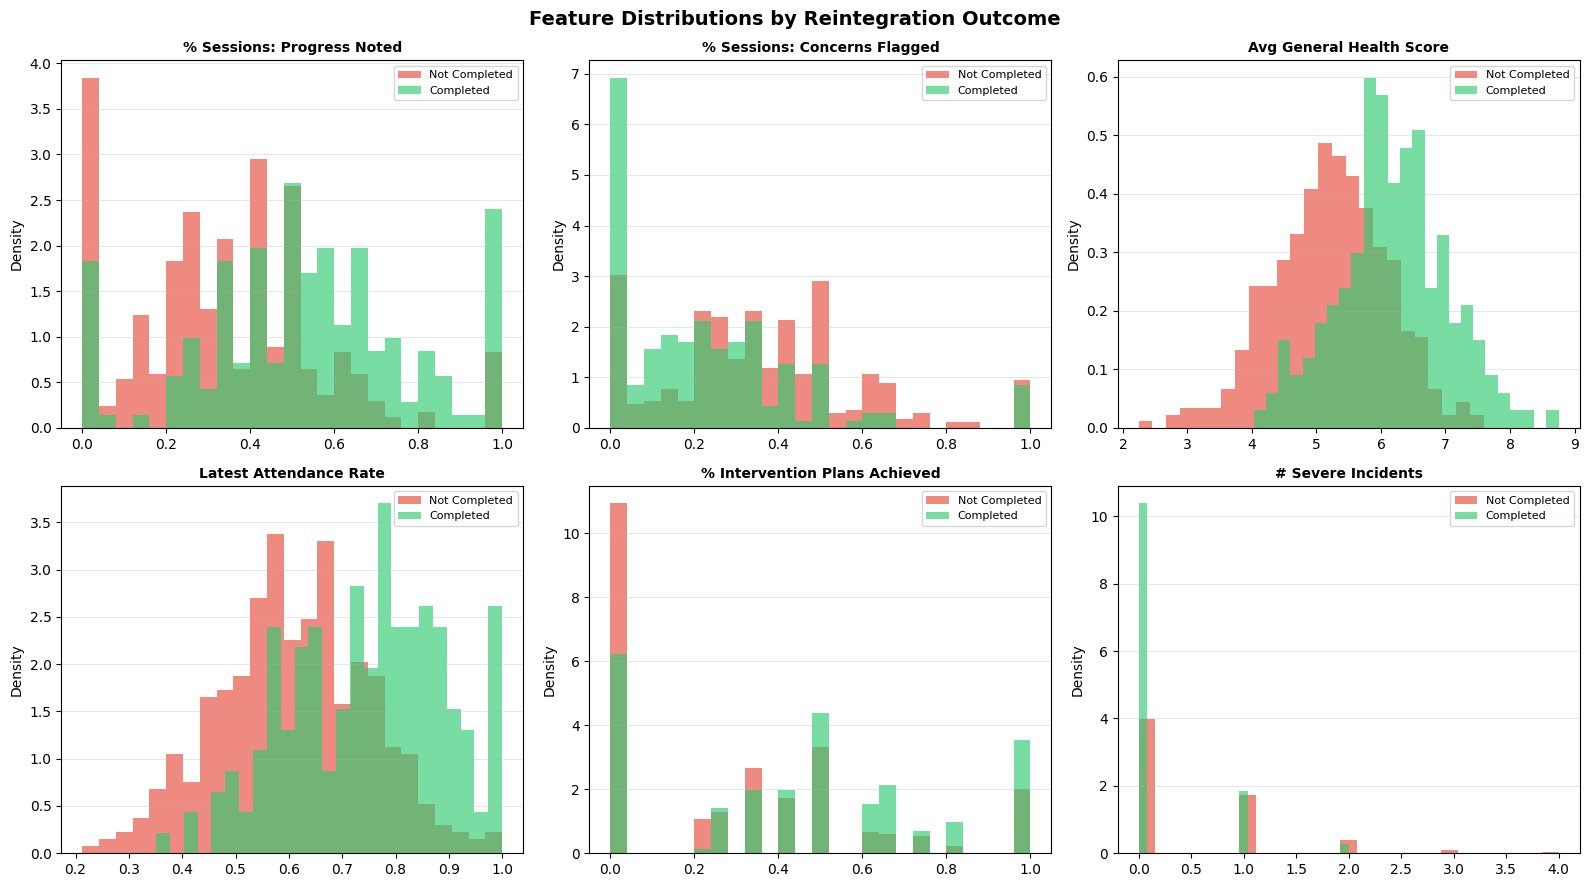

Saved: eda_feature_distributions.png


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA: Feature distributions by outcome
# ─────────────────────────────────────────────────────────────────────────────
COMPLETED     = df_model['target'] == 1
NOT_COMPLETED = df_model['target'] == 0

PLOT_FEATURES = [
    ('pct_progress_noted',       '% Sessions: Progress Noted'),
    ('pct_concerns_flagged',     '% Sessions: Concerns Flagged'),
    ('avg_general_health_score', 'Avg General Health Score'),
    ('latest_attendance_rate',   'Latest Attendance Rate'),
    ('pct_plans_achieved',       '% Intervention Plans Achieved'),
    ('num_severe_incidents',     '# Severe Incidents'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Feature Distributions by Reintegration Outcome', fontsize=14, fontweight='bold')

for ax, (col, title) in zip(axes.flatten(), PLOT_FEATURES):
    vals_yes = df_model.loc[COMPLETED,     col].dropna()
    vals_no  = df_model.loc[NOT_COMPLETED, col].dropna()
    ax.hist(vals_no,  bins=25, alpha=0.65, label='Not Completed', color='#e74c3c', density=True)
    ax.hist(vals_yes, bins=25, alpha=0.65, label='Completed',     color='#2ecc71', density=True)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_feature_distributions.png")


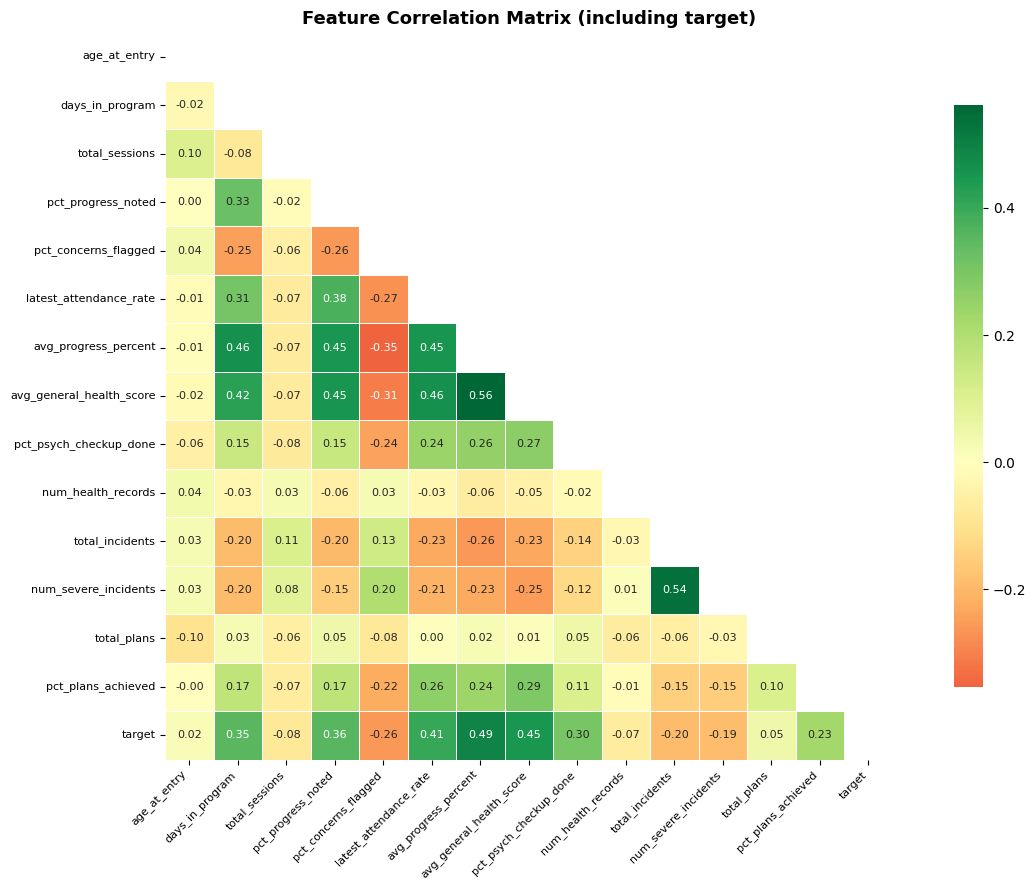

Top correlations with target:
avg_progress_percent        0.4924
avg_general_health_score    0.4478
latest_attendance_rate      0.4070
pct_progress_noted          0.3563
days_in_program             0.3524
pct_psych_checkup_done      0.3039
pct_plans_achieved          0.2274
total_plans                 0.0457
age_at_entry                0.0191
num_health_records         -0.0662
total_sessions             -0.0796
num_severe_incidents       -0.1906
total_incidents            -0.1958
pct_concerns_flagged       -0.2582


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA: Correlation heatmap
# ─────────────────────────────────────────────────────────────────────────────
num_cols = df_model[FEATURE_COLS + ['target']].select_dtypes(include=[np.number])
corr     = num_cols.corr()
mask     = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(13, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix (including target)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations with target:')
target_corr = corr['target'].drop('target').sort_values(ascending=False)
print(target_corr.to_string())


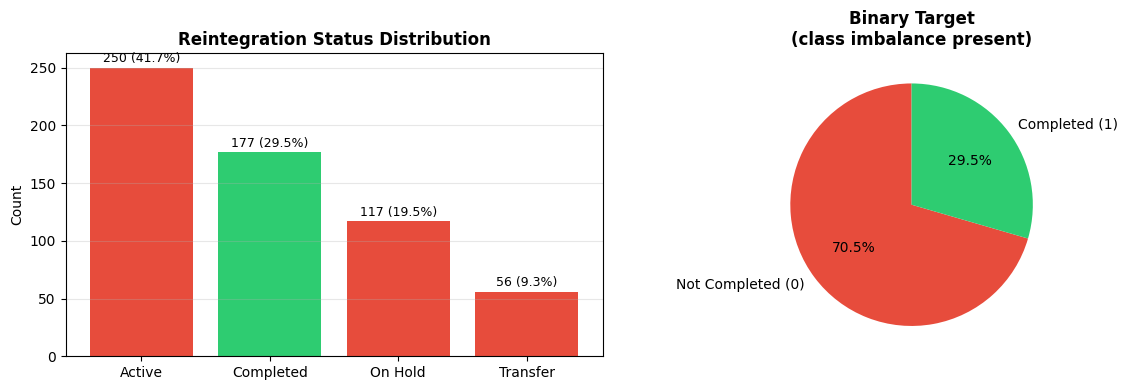

Class imbalance ratio: 2.39:1  (negative:positive)
Implication: use class_weight or threshold tuning; do not rely on accuracy alone.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA: Class distribution
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

status_counts = df_residents['reintegration_status'].value_counts()
colors = ['#2ecc71' if s == 'Completed' else '#e74c3c' for s in status_counts.index]
bars = ax1.bar(status_counts.index, status_counts.values, color=colors)
for bar, cnt in zip(bars, status_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2.,
             bar.get_height() + 2,
             f'{cnt} ({cnt / len(df_residents) * 100:.1f}%)',
             ha='center', va='bottom', fontsize=9)
ax1.set_title('Reintegration Status Distribution', fontweight='bold')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)

target_counts = df_model['target'].value_counts()
ax2.pie(target_counts.values,
        labels=['Not Completed (0)', 'Completed (1)'],
        colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 10})
ax2.set_title('Binary Target\n(class imbalance present)', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = target_counts[0] / target_counts[1]
print(f'Class imbalance ratio: {ratio:.2f}:1  (negative:positive)')
print('Implication: use class_weight or threshold tuning; do not rely on accuracy alone.')


## 3. Modeling & Feature Selection

### Pipeline Architecture

```
ColumnTransformer
  ├── numerical   →  SimpleImputer(median)       →  StandardScaler
  └── categorical →  SimpleImputer(most_frequent) →  OneHotEncoder(handle_unknown='ignore')
          │
          └──>  GradientBoostingClassifier   [primary]
                RandomForestClassifier        [baseline]
```

### Why Gradient Boosting?
- Naturally handles mixed feature types (continuous, binary, count)
- Robust to outliers; does not require normalization (though we scale anyway for consistency)
- Provides Gini-based feature importances for Section 5 analysis
- `subsample < 1.0` acts as stochastic regularization, reducing variance on medium-sized data

### Feature Selection Strategy
All 16 engineered features are retained. In a **predictive** pipeline we do *not* remove
correlated features — multicollinearity hurts interpretation but not prediction accuracy.
The ensemble model naturally distributes splits across correlated features, making VIF
analysis irrelevant here.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PREPROCESSING PIPELINE + TRAIN/TEST SPLIT + MODEL TRAINING
# ─────────────────────────────────────────────────────────────────────────────
CAT_FEATURES = ['safehouse_id', 'referral_source']
NUM_FEATURES = [c for c in FEATURE_COLS if c not in CAT_FEATURES]

X = df_model[FEATURE_COLS].copy()
y = df_model['target'].copy()

# Stratified split preserves class ratio in both subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {len(X_train)} rows  |  positive rate: {y_train.mean():.1%}')
print(f'Test : {len(X_test)} rows  |  positive rate: {y_test.mean():.1%}')

# Sub-pipelines
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_FEATURES),
    ('cat', cat_pipe, CAT_FEATURES),
], remainder='drop')

# Primary model — Gradient Boosting
gbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        min_samples_split=20, min_samples_leaf=10,
        subsample=0.80, random_state=42,
    )),
])

# Baseline — Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=200, max_depth=8,
        class_weight='balanced', random_state=42, n_jobs=-1,
    )),
])

print('\nTraining Gradient Boosting...')
gbm_pipeline.fit(X_train, y_train)
print('Training Random Forest...')
rf_pipeline.fit(X_train, y_train)
print('Both models trained.')


Train: 480 rows  |  positive rate: 29.6%
Test : 120 rows  |  positive rate: 29.2%

Training Gradient Boosting...


Training Random Forest...
Both models trained.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 5-FOLD STRATIFIED CROSS-VALIDATION (training set only)
# ─────────────────────────────────────────────────────────────────────────────
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'f1', 'precision', 'recall']

print('5-Fold Stratified CV Results')
print('=' * 55)
for name, pipe in [('Gradient Boosting', gbm_pipeline), ('Random Forest', rf_pipeline)]:
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'\n{name}:')
    for m in scoring:
        scores = res[f'test_{m}']
        print(f'  {m:<12}  {scores.mean():.4f} +/- {scores.std():.4f}')


5-Fold Stratified CV Results



Gradient Boosting:
  roc_auc       0.8255 +/- 0.0076
  f1            0.5725 +/- 0.0344
  precision     0.6336 +/- 0.0677
  recall        0.5283 +/- 0.0510



Random Forest:
  roc_auc       0.8574 +/- 0.0208
  f1            0.6078 +/- 0.0633
  precision     0.6869 +/- 0.0678
  recall        0.5495 +/- 0.0764


## 4. Evaluation & Interpretation

Models are evaluated on the **held-out test set (20%)** — data the models never saw during
training or cross-validation.

### Business Cost of Errors

| Error Type | Scenario | Cost |
|---|---|---|
| **False Positive** | Predict "ready" when resident is not | **Higher** — premature release into the wild, relapse risk, safety concerns |
| **False Negative** | Predict "not ready" when resident is | Moderate — lost reintegration momentum, held back in safety of safehouse too long |

Because false positives carry higher cost, we bias toward higher **Precision** and select our
operating threshold using the Precision-Recall curve, optimizing for the F0.5 score rather than F1 or default 0.5.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# TEST SET METRICS
# ─────────────────────────────────────────────────────────────────────────────
y_pred_gbm = gbm_pipeline.predict(X_test)
y_prob_gbm = gbm_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf  = rf_pipeline.predict(X_test)
y_prob_rf  = rf_pipeline.predict_proba(X_test)[:, 1]

for name, y_pred, y_prob in [
    ('GRADIENT BOOSTING', y_pred_gbm, y_prob_gbm),
    ('RANDOM FOREST',     y_pred_rf,  y_prob_rf),
]:
    print('=' * 60)
    print(f'{name} — Test Set')
    print('=' * 60)
    print(classification_report(y_test, y_pred,
                                 target_names=['Not Completed', 'Completed']))
    print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
    print(f'  Log Loss : {log_loss(y_test, y_prob):.4f}')
    print()


GRADIENT BOOSTING — Test Set
               precision    recall  f1-score   support

Not Completed       0.83      0.86      0.84        85
    Completed       0.62      0.57      0.60        35

     accuracy                           0.78       120
    macro avg       0.73      0.72      0.72       120
 weighted avg       0.77      0.78      0.77       120

  ROC-AUC  : 0.8289
  Log Loss : 0.4828

RANDOM FOREST — Test Set
               precision    recall  f1-score   support

Not Completed       0.85      0.89      0.87        85
    Completed       0.71      0.63      0.67        35

     accuracy                           0.82       120
    macro avg       0.78      0.76      0.77       120
 weighted avg       0.81      0.82      0.81       120

  ROC-AUC  : 0.8430
  Log Loss : 0.4343



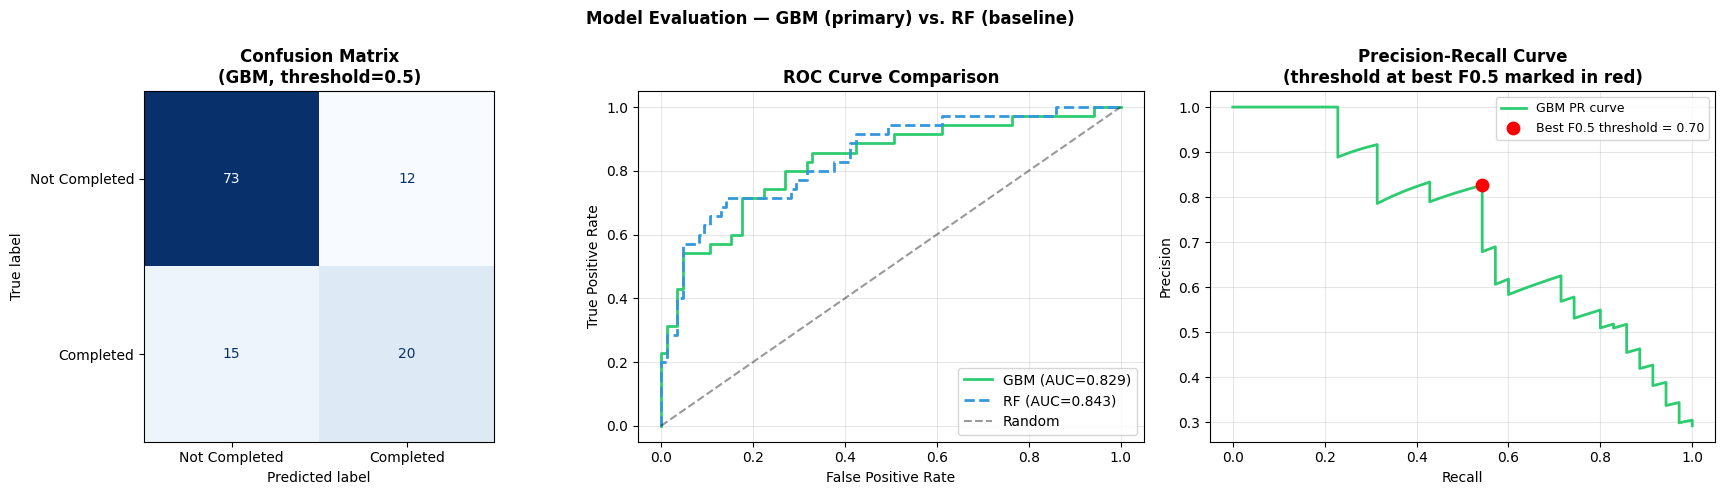

Best F0.5 threshold : 0.701
  Precision : 0.826
  Recall    : 0.543


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION PLOTS
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation — GBM (primary) vs. RF (baseline)',
             fontsize=12, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gbm)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Not Completed', 'Completed']
                       ).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(GBM, threshold=0.5)', fontweight='bold')

# 2. ROC Curves
for nm, y_prob, color, ls in [
    ('GBM', y_prob_gbm, '#2ecc71', '-'),
    ('RF',  y_prob_rf,  '#3498db', '--'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=color, lw=2, linestyle=ls, label=f'{nm} (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve + optimal F0.5 threshold
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_prob_gbm)
f1_arr    = (1 + 0.5**2) * precision_arr * recall_arr / ((0.5**2 * precision_arr) + recall_arr + 1e-9)
best_idx  = int(f1_arr.argmax())
best_thresh = float(thresholds_arr[best_idx])

axes[2].plot(recall_arr, precision_arr, color='#2ecc71', lw=2, label='GBM PR curve')
axes[2].scatter(recall_arr[best_idx], precision_arr[best_idx],
                color='red', zorder=5, s=80,
                label=f'Best F0.5 threshold = {best_thresh:.2f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve\n(threshold at best F0.5 marked in red)',
                  fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eval_model_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best F0.5 threshold : {best_thresh:.3f}')
print(f'  Precision : {precision_arr[best_idx]:.3f}')
print(f'  Recall    : {recall_arr[best_idx]:.3f}')


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE MODEL ARTIFACTS
# ─────────────────────────────────────────────────────────────────────────────
metadata = {
    'model_name':           'reintegration_readiness_gbm',
    'model_version':        '1.0.0',
    'target':               'reintegration_status == Completed',
    'feature_columns':      FEATURE_COLS,
    'numerical_features':   NUM_FEATURES,
    'categorical_features': CAT_FEATURES,
    'roc_auc_test':         round(float(roc_auc_score(y_test, y_prob_gbm)), 4),
    'f0_5_test':            round(float(fbeta_score(y_test, y_pred_gbm, beta=0.5)), 4),
    'best_threshold':       round(best_thresh, 4),
    'trained_on':           '2026-04-06',
}

joblib.dump(gbm_pipeline, 'reintegration_model.joblib')
with open('reintegration_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Model saved   : reintegration_model.joblib')
print('Metadata saved: reintegration_model_metadata.json')
print()
for k, v in metadata.items():
    if k != 'feature_columns':
        print(f'  {k:<25}: {v}')


Model saved   : reintegration_model.joblib
Metadata saved: reintegration_model_metadata.json

  model_name               : reintegration_readiness_gbm
  model_version            : 1.0.0
  target                   : reintegration_status == Completed
  numerical_features       : ['age_at_entry', 'days_in_program', 'total_sessions', 'pct_progress_noted', 'pct_concerns_flagged', 'latest_attendance_rate', 'avg_progress_percent', 'avg_general_health_score', 'pct_psych_checkup_done', 'num_health_records', 'total_incidents', 'num_severe_incidents', 'total_plans', 'pct_plans_achieved']
  categorical_features     : ['safehouse_id', 'referral_source']
  roc_auc_test             : 0.8289
  f0_5_test                : 0.6135
  best_threshold           : 0.7012
  trained_on               : 2026-04-06


## 5. Causal and Relationship Analysis

> **Paradigm B caveat:** This is a strictly predictive pipeline. All relationships described
> below are **correlational** signals, not causal mechanisms. The model reveals which features
> are *predictive* of completion — this does not imply that intervening on those features will
> *cause* reintegration. Confounders not captured here (e.g., family stability, trauma severity,
> external support networks) likely mediate many of these associations.

### What Feature Importances Reveal About Data Structure

**Gini importances** (from the GBM) measure how much each feature reduces prediction uncertainty
across all splits on average. They can over-represent high-cardinality continuous features.

**Permutation importances** (test set) measure actual ROC-AUC degradation when a feature is
randomly shuffled — more conservative and reliable. Features with near-zero permutation
importance are not contributing to out-of-sample accuracy regardless of their Gini rank.

### Interpretive Hypotheses (Correlation, Not Causation)

| Feature Pattern | Likely Data Mechanism |
|---|---|
| High `pct_progress_noted` → Completed | Counselors note progress in residents they already perceive as ready (feedback loop risk) |
| Low `pct_concerns_flagged` → Completed | Fewer active flags reduces formal barriers to reintegration approval |
| High `pct_plans_achieved` → Completed | Plan completion may be a formal exit requirement *and* a behavioral readiness signal |
| High `avg_general_health_score` → Completed | Physical/psychological wellness is a prerequisite for safe community reintegration |
| Zero `num_severe_incidents` → Completed | Policy may require incident-free periods; also reflects genuine behavioral stability |
| `days_in_program` non-linear | Very short stays (too early) and very long stays (stuck) both correlate with non-completion |

**Honest limitation:** Counselor-generated features (`pct_progress_noted`, `pct_concerns_flagged`)
may encode implicit bias or prior beliefs about a resident's trajectory. Future work should
validate against blinded, structured assessments.


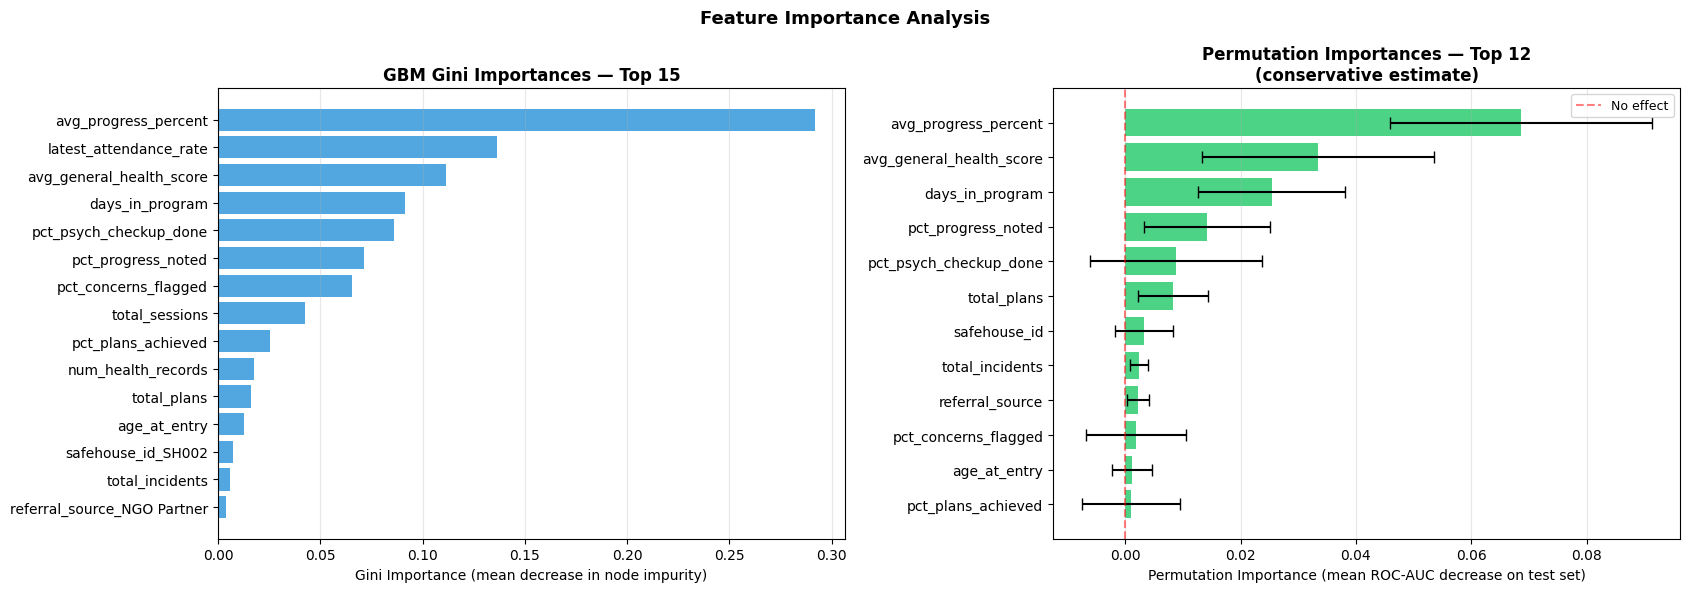

Top 10 features by permutation importance (test set):
                 feature  mean_imp  std_imp
    avg_progress_percent    0.0686   0.0227
avg_general_health_score    0.0334   0.0201
         days_in_program    0.0254   0.0127
      pct_progress_noted    0.0141   0.0109
  pct_psych_checkup_done    0.0088   0.0149
             total_plans    0.0083   0.0061
            safehouse_id    0.0032   0.0050
         total_incidents    0.0024   0.0015
         referral_source    0.0022   0.0019
    pct_concerns_flagged    0.0018   0.0086


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE IMPORTANCES — Gini + Permutation
# ─────────────────────────────────────────────────────────────────────────────

# Gini importances — expand OHE feature names to match GBM's internal feature count
ohe_names = (
    gbm_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(CAT_FEATURES)
    .tolist()
)
all_names = NUM_FEATURES + ohe_names
gini_imp  = gbm_pipeline.named_steps['classifier'].feature_importances_

gini_df = (
    pd.DataFrame({'feature': all_names, 'importance': gini_imp})
    .sort_values('importance', ascending=False)
    .head(15)
)

# Permutation importances on test set — uses original FEATURE_COLS
perm = permutation_importance(
    gbm_pipeline, X_test, y_test,
    n_repeats=25, random_state=42, scoring='roc_auc', n_jobs=-1
)
perm_df = (
    pd.DataFrame({
        'feature':  FEATURE_COLS,
        'mean_imp': perm.importances_mean,
        'std_imp':  perm.importances_std,
    })
    .sort_values('mean_imp', ascending=False)
    .head(12)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Feature Importance Analysis', fontsize=13, fontweight='bold')

ax1.barh(gini_df['feature'][::-1], gini_df['importance'][::-1],
         color='#3498db', alpha=0.85)
ax1.set_xlabel('Gini Importance (mean decrease in node impurity)')
ax1.set_title('GBM Gini Importances — Top 15', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax2.barh(perm_df['feature'][::-1], perm_df['mean_imp'][::-1],
         xerr=perm_df['std_imp'][::-1], color='#2ecc71', alpha=0.85, capsize=4)
ax2.axvline(0, color='red', linestyle='--', alpha=0.5, label='No effect')
ax2.set_xlabel('Permutation Importance (mean ROC-AUC decrease on test set)')
ax2.set_title('Permutation Importances — Top 12\n(conservative estimate)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by permutation importance (test set):')
print(perm_df[['feature', 'mean_imp', 'std_imp']].head(10).to_string(index=False))


## 6. Deployment Notes

### Architecture

```
[React Frontend]
      |
      | GET /api/residents/{id}/reintegration-readiness
      v
[.NET 10 Minimal API]   <──  appsettings.json (PredictionService:BaseUrl)
      |
      | POST /predict  (JSON feature payload)
      v
[Python FastAPI — predict_service.py]
      |
      | joblib.load()
      v
[reintegration_model.joblib]
```

### Component Files

| File | Purpose |
|---|---|
| `ml-pipelines/reintegration_model.joblib` | Trained sklearn pipeline (preprocessing + GBM) |
| `ml-pipelines/reintegration_model_metadata.json` | Feature list, threshold, version info |
| `ml-pipelines/predict_service.py` | FastAPI microservice wrapping the model |
| `deployment/ReintegrationReadinessEndpoint.cs` | .NET 10 minimal API endpoint |
| `deployment/ReintegrationReadiness.tsx` | React/TS dashboard component |

### Startup

```bash
# Install dependencies
pip install fastapi uvicorn joblib scikit-learn pandas numpy

# Start prediction service (from ml-pipelines/ directory)
uvicorn predict_service:app --host 0.0.0.0 --port 8001
```

### Request / Response Schema

```json
POST /predict
{
  "resident_id": 42, "safehouse_id": "SH002", "age_at_entry": 16,
  "days_in_program": 220, "referral_source": "NGO Partner",
  "total_sessions": 12, "pct_progress_noted": 0.83,
  "pct_concerns_flagged": 0.08, "latest_attendance_rate": 0.92,
  "avg_progress_percent": 78.5, "avg_general_health_score": 8.1,
  "pct_psych_checkup_done": 0.80, "num_health_records": 5,
  "total_incidents": 0, "num_severe_incidents": 0,
  "total_plans": 4, "pct_plans_achieved": 0.75
}

Response
{
  "resident_id": 42,
  "reintegration_probability": 0.7812,
  "prediction": "Ready",
  "risk_tier": "High Readiness",
  "threshold_used": 0.42
}
```


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# PREDICTION FUNCTION + SMOKE TESTS
# Mirrors the logic in predict_service.py for local verification.
# ─────────────────────────────────────────────────────────────────────────────
def predict_readiness(resident_features: dict,
                      metadata_path: str = 'reintegration_model_metadata.json',
                      model_path: str = 'reintegration_model.joblib') -> dict:
    with open(metadata_path) as f:
        meta = json.load(f)
    model     = joblib.load(model_path)
    threshold = meta['best_threshold']
    df_in     = pd.DataFrame([resident_features])[meta['feature_columns']]
    prob      = float(model.predict_proba(df_in)[0, 1])
    prediction = 'Ready' if prob >= threshold else 'Not Ready'
    if prob >= 0.70:
        risk_tier = 'High Readiness'
    elif prob >= threshold:
        risk_tier = 'Moderate Readiness'
    else:
        risk_tier = 'Low Readiness'
    return {
        'resident_id':               resident_features.get('resident_id'),
        'reintegration_probability': round(prob, 4),
        'prediction':                prediction,
        'risk_tier':                 risk_tier,
        'threshold_used':            round(threshold, 4),
    }


HIGH_EXAMPLE = {
    'resident_id': 42, 'safehouse_id': 'SH002', 'age_at_entry': 16,
    'days_in_program': 220, 'referral_source': 'NGO Partner',
    'total_sessions': 12,         'pct_progress_noted': 0.83,
    'pct_concerns_flagged': 0.08, 'latest_attendance_rate': 0.92,
    'avg_progress_percent': 78.5, 'avg_general_health_score': 8.1,
    'pct_psych_checkup_done': 0.80, 'num_health_records': 5,
    'total_incidents': 0,           'num_severe_incidents': 0,
    'total_plans': 4,               'pct_plans_achieved': 0.75,
}

LOW_EXAMPLE = {
    'resident_id': 99, 'safehouse_id': 'SH001', 'age_at_entry': 14,
    'days_in_program': 45, 'referral_source': 'Police',
    'total_sessions': 2,           'pct_progress_noted': 0.50,
    'pct_concerns_flagged': 0.50,  'latest_attendance_rate': 0.55,
    'avg_progress_percent': 32.0,  'avg_general_health_score': 4.2,
    'pct_psych_checkup_done': 0.25, 'num_health_records': 2,
    'total_incidents': 3,           'num_severe_incidents': 2,
    'total_plans': 1,               'pct_plans_achieved': 0.0,
}

for label, ex in [('HIGH readiness', HIGH_EXAMPLE), ('LOW readiness', LOW_EXAMPLE)]:
    result = predict_readiness(ex)
    print(f'--- {label} ---')
    for k, v in result.items():
        print(f'  {k:<32}: {v}')
    print()

print('Pipeline complete. Model is ready for deployment.')


--- HIGH readiness ---
  resident_id                     : 42
  reintegration_probability       : 0.9894
  prediction                      : Ready
  risk_tier                       : High Readiness
  threshold_used                  : 0.7012

--- LOW readiness ---
  resident_id                     : 99
  reintegration_probability       : 0.0034
  prediction                      : Not Ready
  risk_tier                       : Low Readiness
  threshold_used                  : 0.7012

Pipeline complete. Model is ready for deployment.
